# **Goal:** Predict Hypertension

## 1. Basic EDA

1. Load the dataset
2. print `head()`
3. check for missing values
4. look at distributions
5. identify target variable

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## Load NHANES Data
demo = pd.read_sas("data/DEMO_J.XPT")
bpq = pd.read_sas("data/BPQ_J.XPT")
bpx = pd.read_sas("data/BPX_J.XPT")

## Merge datasets
df = demo.merge(bpq, on="SEQN", how="left")
df = df.merge(bpx, on="SEQN", how="left")

print(df.shape)
df.head()

(9254, 76)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,BPAEN1,BPXSY2,BPXDI2,BPAEN2,BPXSY3,BPXDI3,BPAEN3,BPXSY4,BPXDI4,BPAEN4
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,NaN,NaN,NaN,NaN,202.0,62.0,2.0,198.0,74.0,2.0
3,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,...,2.0,114.0,70.0,2.0,108.0,76.0,2.0,NaN,NaN,NaN
4,93707.0,10.0,2.0,1.0,13.0,NaN,5.0,7.0,2.0,158.0,...,2.0,128.0,46.0,2.0,128.0,58.0,2.0,NaN,NaN,NaN


#### Choosing target variable and relavant features

In [12]:
## Hypertention Outcome Variable

# BPQ020: "Ever told you had high blood pressure?"
# 1 = Yes, 2 = No, 7 = Refused, 9 = Don't know

df['hypertension'] = df['BPQ020'].replace({1: 1, 2: 0}).astype('float')
df = df.dropna(subset=['hypertension'])
df['hypertension'].value_counts(normalize=True)

## Select Features for Model
features = [
    "RIDAGEYR",   # age
    "RIAGENDR",   # sex
    "RIDRETH3",   # race/ethnicity
    "BPXSY1",     # systolic BP
    "BPXDI1"      # diastolic BP
]

df_model = df[features + ['hypertension']].copy()
# df_model = df_model.dropna()

df_model.head()

,RIDAGEYR,RIAGENDR,RIDRETH3,BPXSY1,BPXDI1,hypertension
2,66.0,2.0,4.0,NaN,NaN,1.0
3,18.0,1.0,6.0,112.0,74.0,0.0
5,66.0,2.0,6.0,NaN,NaN,1.0
6,75.0,2.0,4.0,120.0,66.0,1.0
8,56.0,1.0,6.0,108.0,68.0,0.0


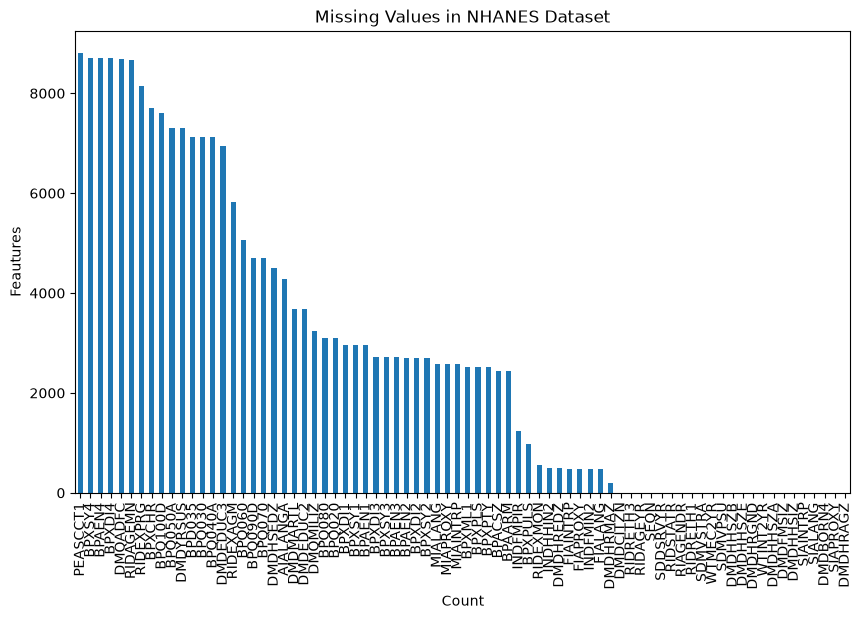

np.int64(3093)

In [ ]:
## Identify missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
missing_values.plot(kind='bar')
plt.title('Missing Values in NHANES Dataset')
plt.xlabel('Count')
plt.ylabel('Feautures')
plt.show()

## missing values for our target variable
missing_values["BPQ020"]

In [ ]:
df_modle

## 2. Feature Engineering

- age buckets
- num